# Importing the Dog vs Cat Dataset from Kaggle

In [60]:
# Configuring the path for kaggle.json file
!kaggle competitions download -c dogs-vs-cats


dogs-vs-cats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [1]:
# Extracting the dataset

from zipfile import ZipFile

dataset = 'dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print("Data Extraction completed")

Data Extraction completed


In [2]:
# Extracting the train zip file

from zipfile import ZipFile

dataset = 'train.zip'
with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print("Train data extraction compelted")

Train data extraction compelted


In [3]:
# Extracting the Test Zip File

from zipfile import ZipFile

dataset = 'test1.zip'
with ZipFile(dataset, 'r') as zip:
    zip.extractall()
    print("Test File extracted")

Test File extracted


In [61]:
# Printing names of images
import os

file_names = os.listdir('train/')
print(file_names)

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg', 'cat.10000.jpg', 'cat.10001.jpg', 'cat.10002.jpg', 'cat.10003.jpg', 'cat.10004.jpg', 'cat.10005.jpg', 'cat.10006.jpg', 'cat.10007.jpg', 'cat.10008.jpg', 'cat.10009.jpg', 'cat.1001.jpg', 'cat.10010.jpg', 'cat.10011.jpg', 'cat.10012.jpg', 'cat.10013.jpg', 'cat.10014.jpg', 'cat.10015.jpg', 'cat.10016.jpg', 'cat.10017.jpg', 'cat.10018.jpg', 'cat.10019.jpg', 'cat.1002.jpg', 'cat.10020.jpg', 'cat.10021.jpg', 'cat.10022.jpg', 'cat.10023.jpg', 'cat.10024.jpg', 'cat.10025.jpg', 'cat.10026.jpg', 'cat.10027.jpg', 'cat.10028.jpg', 'cat.10029.jpg', 'cat.1003.jpg', 'cat.10030.jpg', 'cat.10031.jpg', 'cat.10032.jpg', 'cat.10033.jpg', 'cat.10034.jpg', 'cat.10035.jpg', 'cat.10036.jpg', 'cat.10037.jpg', 'cat.10038.jpg', 'cat.10039.jpg', 'cat.1004.jpg', 'cat.10040.jpg', 'cat.10041.jpg', 'cat.10042.jpg', 'cat.10043.jpg', 'cat.10044.jpg', 'cat.10045.jpg', 'cat.10046.jpg', 'cat.10047.jpg', 'cat.10048.jpg', 'cat.10049.jpg', 'cat.1005.jpg'

# Importing Dependencies

In [62]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

# Image of Dogs and Cats

<function matplotlib.pyplot.show(close=None, block=None)>

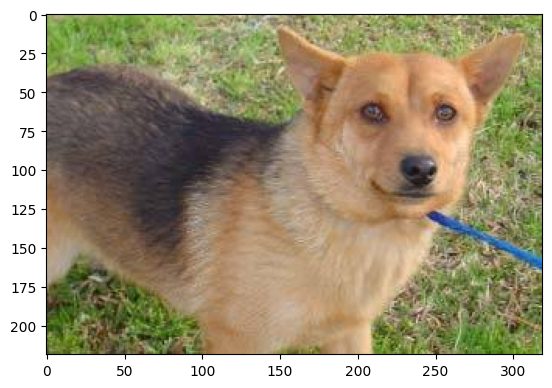

In [63]:
# Viewing the Dog image

img = mpimg.imread('train/dog.6053.jpg')
impplt = plt.imshow(img)
plt.show

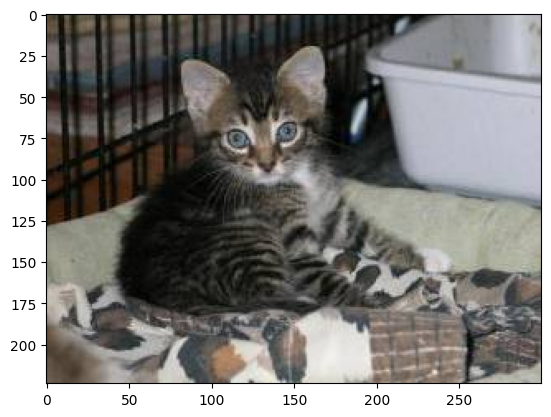

In [66]:
# Viewing the Cat image

img = mpimg.imread('train/cat.12.jpg')
implt = plt.imshow(img)
plt.show()

In [65]:
file_names = os.listdir('train/')

for i in range(5):
    name = file_names[i]
    print(name)
    print(name[0:3])

cat.0.jpg
cat
cat.1.jpg
cat
cat.10.jpg
cat
cat.100.jpg
cat
cat.1000.jpg
cat


In [67]:
file_names = os.listdir('train/')
dog_count = 0
cat_count = 0


for img in file_names:
    name = img[0:3]

    if name =='dog':
        dog_count+=1
    else:
        cat_count+=1

print('Number of dog images:', dog_count)
print('Number of Cat Images:', cat_count)

Number of dog images: 12500
Number of Cat Images: 12500


# Resizing all Images

In [69]:
# Creating a folder for resized images

os.mkdir('Image Resized/')

In [70]:
import os
import random
from PIL import Image

original_folder = 'train/'
resized_folder = 'Image Resized/'

# Get all filenames
all_files = os.listdir(original_folder)

# Shuffle the list randomly
random.shuffle(all_files)

# Take first 2000 images after shuffling
selected_files = all_files[:2000]

for filename in selected_files:
    img_path = os.path.join(original_folder, filename)

    # Open, resize, and convert to RGB
    img = Image.open(img_path)
    img = img.resize((224, 224))
    img = img.convert('RGB')

    # Save to new folder
    newImgPath = os.path.join(resized_folder, filename)
    img.save(newImgPath)


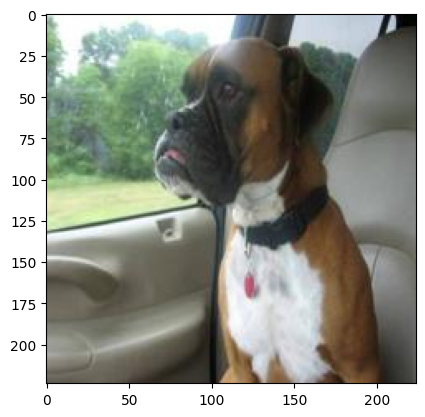

In [73]:
# Viewing resized image

img = mpimg.imread('Image Resized/dog.5065.jpg')
imgplt = plt.imshow(img)
plt.show()

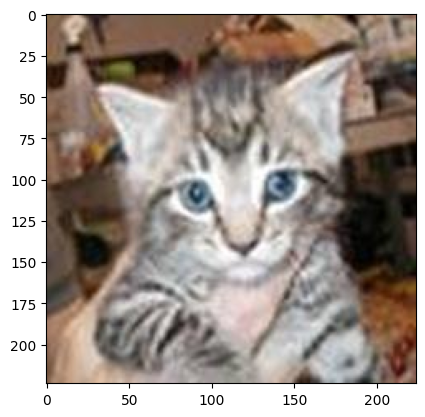

In [74]:
# Viewing cat image

img = mpimg.imread('Image Resized/cat.4363.jpg')
imgplt = plt.imshow(img)
plt.show()

# Creating Labels for resized images of dog and cats

Cat --> 0

Dog --> 1

In [76]:
# Creating a for loop for assign lables

filenames = os.listdir('Image Resized/')

labels = []

for i in range(2000):
    file_name = filenames[i]
    label_str = file_name[0:3]

    if label_str =='dog':
        labels.append(1)

    else:
        labels.append(0)

In [77]:
print(filenames[0:5])
print(len(filenames))

['cat.10002.jpg', 'cat.10013.jpg', 'cat.10025.jpg', 'cat.10041.jpg', 'cat.10047.jpg']
2000


In [78]:
print(labels[0:5])
print(len(labels))

[0, 0, 0, 0, 0]
2000


In [79]:
# Counting the no of images in cats and dogs 

values, counts = np.unique(labels, return_counts = True)
print(values)
print(counts)

[0 1]
[ 985 1015]


# Converting all resized images to Numpy Array

In [80]:
import cv2
import glob


In [81]:
image_directory = 'Image Resized'
image_extension = ['png', 'jpg']

files = []
for e in image_extension:
    files.extend(glob.glob(os.path.join(image_directory, '*.' + e)))

dog_cat_images = []
for file in files:
    img = cv2.imread(file)
    if img is not None:
        dog_cat_images.append(img)

dog_cat_images = np.asarray(dog_cat_images)

In [82]:
print(dog_cat_images)

[[[[ 54  59  57]
   [ 55  60  58]
   [ 56  61  59]
   ...
   [ 57  69  73]
   [ 57  69  73]
   [ 57  69  73]]

  [[ 54  59  57]
   [ 55  60  58]
   [ 56  61  59]
   ...
   [ 57  69  73]
   [ 57  69  73]
   [ 57  69  73]]

  [[ 55  60  58]
   [ 56  61  59]
   [ 57  62  60]
   ...
   [ 57  69  73]
   [ 57  69  73]
   [ 57  69  73]]

  ...

  [[ 42  53  61]
   [ 42  53  61]
   [ 42  53  61]
   ...
   [ 26  34  41]
   [ 18  26  33]
   [ 12  20  27]]

  [[ 42  53  61]
   [ 42  53  61]
   [ 42  53  61]
   ...
   [ 24  32  39]
   [ 16  24  31]
   [ 10  18  25]]

  [[ 42  53  61]
   [ 42  53  61]
   [ 42  53  61]
   ...
   [ 24  32  39]
   [ 16  24  31]
   [ 10  18  25]]]


 [[[  4   4   4]
   [  5   5   5]
   [  6   6   6]
   ...
   [  1   6   4]
   [  3   4   0]
   [  4   5   1]]

  [[  4   4   4]
   [  5   5   5]
   [  6   6   6]
   ...
   [  1   6   4]
   [  5   6   4]
   [  6   7   3]]

  [[  4   4   4]
   [  5   5   5]
   [  6   6   6]
   ...
   [  1   6   4]
   [  5   6   4]
   [  7   8

In [83]:
type(dog_cat_images)

numpy.ndarray

In [84]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [85]:
X = dog_cat_images
Y = np.asarray(labels)

In [86]:
print(X)

[[[[ 54  59  57]
   [ 55  60  58]
   [ 56  61  59]
   ...
   [ 57  69  73]
   [ 57  69  73]
   [ 57  69  73]]

  [[ 54  59  57]
   [ 55  60  58]
   [ 56  61  59]
   ...
   [ 57  69  73]
   [ 57  69  73]
   [ 57  69  73]]

  [[ 55  60  58]
   [ 56  61  59]
   [ 57  62  60]
   ...
   [ 57  69  73]
   [ 57  69  73]
   [ 57  69  73]]

  ...

  [[ 42  53  61]
   [ 42  53  61]
   [ 42  53  61]
   ...
   [ 26  34  41]
   [ 18  26  33]
   [ 12  20  27]]

  [[ 42  53  61]
   [ 42  53  61]
   [ 42  53  61]
   ...
   [ 24  32  39]
   [ 16  24  31]
   [ 10  18  25]]

  [[ 42  53  61]
   [ 42  53  61]
   [ 42  53  61]
   ...
   [ 24  32  39]
   [ 16  24  31]
   [ 10  18  25]]]


 [[[  4   4   4]
   [  5   5   5]
   [  6   6   6]
   ...
   [  1   6   4]
   [  3   4   0]
   [  4   5   1]]

  [[  4   4   4]
   [  5   5   5]
   [  6   6   6]
   ...
   [  1   6   4]
   [  5   6   4]
   [  6   7   3]]

  [[  4   4   4]
   [  5   5   5]
   [  6   6   6]
   ...
   [  1   6   4]
   [  5   6   4]
   [  7   8

In [87]:
print(Y)

[0 0 0 ... 1 1 1]


# Train Test Split

In [88]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [89]:
print(X.shape, X_test.shape, X_train.shape)

(2000, 224, 224, 3) (400, 224, 224, 3) (1600, 224, 224, 3)


1600 --> training images

400 --> test images



# Scalling the Data ( Normalize )

In [93]:
# Scaling between 0 and 1
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [94]:
print(X_train_scaled)

[[[[0.31372549 0.36078431 0.3372549 ]
   [0.4627451  0.50980392 0.48627451]
   [0.64313725 0.69019608 0.66666667]
   ...
   [0.42352941 0.43529412 0.45490196]
   [0.41568627 0.42745098 0.44705882]
   [0.40392157 0.41568627 0.43529412]]

  [[0.30196078 0.34901961 0.3254902 ]
   [0.37647059 0.42352941 0.4       ]
   [0.4627451  0.50980392 0.48627451]
   ...
   [0.46666667 0.47843137 0.49803922]
   [0.46666667 0.47843137 0.49803922]
   [0.46666667 0.47843137 0.49803922]]

  [[0.30980392 0.35294118 0.34117647]
   [0.31764706 0.36078431 0.34901961]
   [0.33333333 0.37647059 0.36470588]
   ...
   [0.42352941 0.43529412 0.45490196]
   [0.41176471 0.42352941 0.44313725]
   [0.40784314 0.41960784 0.43921569]]

  ...

  [[0.23137255 0.25098039 0.24313725]
   [0.22352941 0.24313725 0.23529412]
   [0.21568627 0.23529412 0.23137255]
   ...
   [0.45882353 0.49019608 0.55686275]
   [0.43529412 0.46666667 0.53333333]
   [0.42352941 0.45490196 0.52156863]]

  [[0.22745098 0.24705882 0.23921569]
   [0.2

# Building the Nueral Network

In [124]:
import tensorflow as tf
import tensorflow_hub as hub

In [ ]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

# pretrained_model = hub.KerasLayer(mobilenet_model, input_shape = (224,224,3), trainable = False)



In [126]:
num_of_classes = 2

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),

)
base_model.trainable = False  # Freeze base model

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dense(num_of_classes) 
])

model.summary()

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1000)           │     3,538,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │         2,002 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,540,986 (13.51 MB)

 Trainable params: 2,002 (7.82 KB)

 Non-trainable params: 3,538,984 (13.50 MB)

In [128]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['acc']
)

In [129]:
# Check if CUDA (GPU) is available
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    device = 'cuda'
else:
    print("Using CPU - consider installing CUDA for faster inference")
    device = 'cpu'

CUDA available: True
GPU device: NVIDIA GeForce GTX 1650


In [130]:
model.fit(X_train_scaled, Y_train, epochs=10)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 481ms/step - acc: 0.6812 - loss: 0.6855
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 483ms/step - acc: 0.9187 - loss: 0.6627
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 461ms/step - acc: 0.9444 - loss: 0.6410
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 455ms/step - acc: 0.9500 - loss: 0.6204
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 453ms/step - acc: 0.9494 - loss: 0.6009
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 451ms/step - acc: 0.9550 - loss: 0.5820
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 456ms/step - acc: 0.9563 - loss: 0.5641
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 452ms/step - acc: 0.9563 - loss: 0.5469
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 450ms/step - acc: 0.9563 - loss: 0.5305
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 453ms/step - acc: 0.9563 - loss: 0.5148


In [131]:
score, acc = model.evaluate(X_test_scaled, Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 518ms/step - acc: 0.9425 - loss: 0.5093


In [132]:
print('Test Loass:', score)
print('Test Accuracy: ', acc)

Test Loass: 0.5092901587486267
Test Accuracy:  0.9424999952316284


# Predictive System

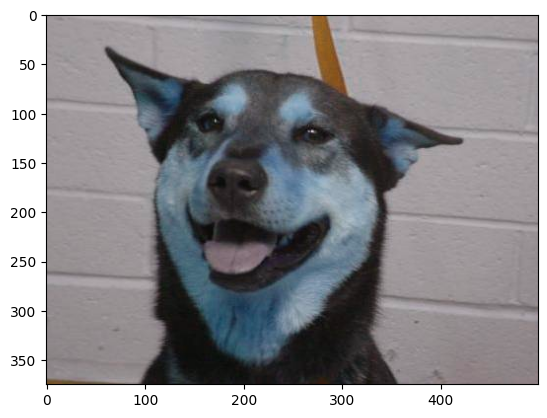

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[-0.24357867  0.26670772]]
1
The Image is Dog


In [134]:
input_image_path = input('Enter the path of the image:')

input_image = cv2.imread(input_image_path)

plt.imshow(input_image)
plt.show()

input_image_resize = cv2.resize(input_image, (224,224))
input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1, 224,224,3])  # For one instance

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_prediction_label = np.argmax(input_prediction)
print(input_prediction_label)

if input_prediction_label ==0:
    print('The image is CAT')

else:
    print('The Image is Dog')

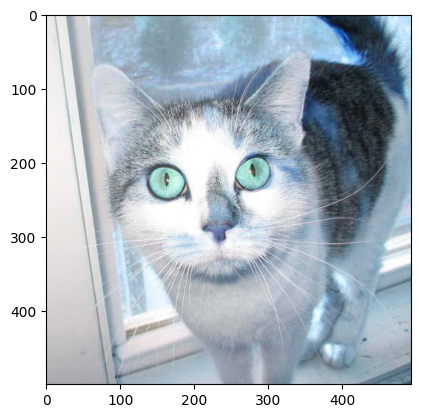

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[ 0.2506888 -0.276438 ]]
0
The image is CAT


In [135]:
input_image_path = input('Enter the path of the image:')

input_image = cv2.imread(input_image_path)

plt.imshow(input_image)
plt.show()

input_image_resize = cv2.resize(input_image, (224,224))
input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1, 224,224,3])  # For one instance

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_prediction_label = np.argmax(input_prediction)
print(input_prediction_label)

if input_prediction_label ==0:
    print('The image is CAT')

else:
    print('The Image is Dog')

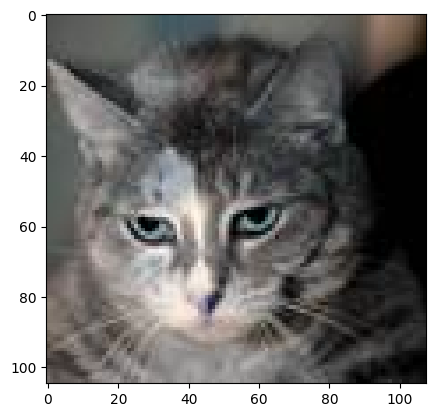

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[ 0.32981583 -0.34483227]]
0
The image is CAT


In [146]:
input_image_path = input('Enter the path of the image:')

input_image = cv2.imread(input_image_path)

plt.imshow(input_image)
plt.show()

input_image_resize = cv2.resize(input_image, (224,224))
input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1, 224,224,3])  # For one instance

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_prediction_label = np.argmax(input_prediction)
print(input_prediction_label)

if input_prediction_label ==0:
    print('The image is CAT')

else:
    print('The Image is Dog')

# Prediction for All Test Images

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

test_image_path = 'test1/'
list_dir = os.listdir(test_image_path)

for filename in list_dir:
    input_image_path = os.path.join(test_image_path, filename)

    # Read image
    input_image = cv2.imread(input_image_path)

    plt.imshow(input_image)
    plt.show()

    input_image_resize = cv2.resize(input_image, (224,224))
    input_image_scaled = input_image_resize/255

    image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

    input_prediction = model.predict(image_reshaped)

    print(input_prediction)

    input_prediction_label = np.argmax(input_prediction)
    print(input_prediction_label)

    if input_prediction_label ==0:
        print('The image is CAT')

    else:
        print('The Image is Dog')
        

In [ ]:
import os
import cv2
import numpy as np
import base64
from io import BytesIO
from PIL import Image
import random
from fpdf import FPDF

test_image_path = 'test1/'
list_dir = os.listdir(test_image_path)

# Randomly select 200 images
random.seed(42)
selected_images = random.sample(list_dir, 200)

# HTML content
html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>Image Predictions</title>
</head>
<body>
<h1>Image Predictions</h1>
<div style="display:flex; flex-wrap:wrap;">
"""

# PDF setup
pdf = FPDF()
pdf.set_auto_page_break(auto=True, margin=15)
pdf.add_page()
pdf.set_font("Arial", 'B', 16)
pdf.cell(0, 10, "Image Predictions", ln=True, align='C')
pdf.ln(10)

# PDF layout settings
pdf_x_start = 10
pdf_y_start = pdf.get_y()
pdf_x = pdf_x_start
pdf_y = pdf_y_start
img_width = 60  # Width of each image in PDF
img_height = 60
x_margin = 10
y_margin = 15
page_width = pdf.w - 20  # Considering left+right margins

for idx, filename in enumerate(selected_images, start=1):
    input_image_path = os.path.join(test_image_path, filename)

    # Read image
    input_image = cv2.imread(input_image_path)
    if input_image is None:
        print(f"Skipping {filename}, could not read image.")
        continue

    input_image_rgb = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

    # Prepare image for prediction
    input_image_resize = cv2.resize(input_image_rgb, (224,224))
    input_image_scaled = input_image_resize / 255.0
    image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

    # Make prediction
    input_prediction = model.predict(image_reshaped)
    input_prediction_label = np.argmax(input_prediction)
    label = 'CAT' if input_prediction_label == 0 else 'DOG'

    # Convert image to base64 for HTML
    pil_img = Image.fromarray(input_image_rgb)
    buffered = BytesIO()
    pil_img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()

    # Add to HTML
    html_content += f"""
    <div style="display:inline-block; text-align:center; margin:10px;">
        <img src="data:image/png;base64,{img_str}" width="150"/><br>
        <span>{idx}. {filename} - Prediction: {label}</span>
    </div>
    """

    # Save temporary image for PDF
    temp_path = f"temp_{idx}.png"
    pil_img.save(temp_path)

    # Add image to PDF
    if pdf_x + img_width > page_width:
        pdf_x = pdf_x_start
        pdf_y += img_height + y_margin

    pdf.image(temp_path, x=pdf_x, y=pdf_y, w=img_width, h=img_height)
    pdf.set_xy(pdf_x, pdf_y + img_height + 2)
    pdf.set_font("Arial", '', 10)
    pdf.multi_cell(img_width, 5, f"{idx}. {filename}\nPrediction: {label}", align='C')

    pdf_x += img_width + x_margin

    # Remove temporary image
    os.remove(temp_path)

html_content += "</div></body></html>"

# Save HTML
with open("predictions.html", "w") as f:
    f.write(html_content)
print("HTML file saved as predictions.html")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━